In [1]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
dazes_021D=pd.read_csv('dazes_021D.csv')

In [5]:
dazes_021D

,Unnamed: 0,polyid,epoch,rslc3,orbfile,daz,cc_azi,cc_range,daz_iono,daz_SET
0,0,9507,2022-08-26,2022-09-19,S1A_OPER_AUX_POEORB_OPOD_20220915T081834_V2022...,-0.001054,0.00176,0.05080,-0.002826,-0.000846
1,1,9507,2022-09-07,2022-09-19,S1A_OPER_AUX_POEORB_OPOD_20220927T081735_V2022...,0.001406,0.01063,0.00951,0.000209,-0.000507
2,2,9507,2022-10-01,2022-09-19,S1A_OPER_AUX_POEORB_OPOD_20221021T081749_V2022...,-0.003177,0.00167,0.01509,-0.002666,0.001393
3,3,9507,2022-10-13,2022-09-19,S1A_OPER_AUX_POEORB_OPOD_20221102T084242_V2022...,-0.000197,-0.00421,0.06965,-0.000440,0.000580
4,4,9507,2022-10-25,2022-09-19,S1A_OPER_AUX_POEORB_OPOD_20221114T081821_V2022...,-0.002753,-0.00035,0.06276,-0.000440,-0.000113
...,...,...,...,...,...,...,...,...,...,...
424,424,9507,2024-10-26,2024-10-14,S1A_OPER_AUX_POEORB_OPOD_20241115T070633_V2024...,-0.002891,0.00893,0.02298,0.001293,0.001225
425,425,9507,2024-11-07,2024-10-14,S1A_OPER_AUX_POEORB_OPOD_20241127T070546_V2024...,-0.004098,0.01751,0.03125,0.001412,0.001071
426,426,9507,2024-11-19,2024-10-14,S1A_OPER_AUX_POEORB_OPOD_20241209T070604_V2024...,-0.001750,0.02867,0.02592,0.000661,0.000444
427,427,9507,2024-12-25,2024-10-14,S1A_OPER_AUX_POEORB_OPOD_20250114T070631_V2024...,0.000096,0.03400,0.03966,-0.000309,0.002073


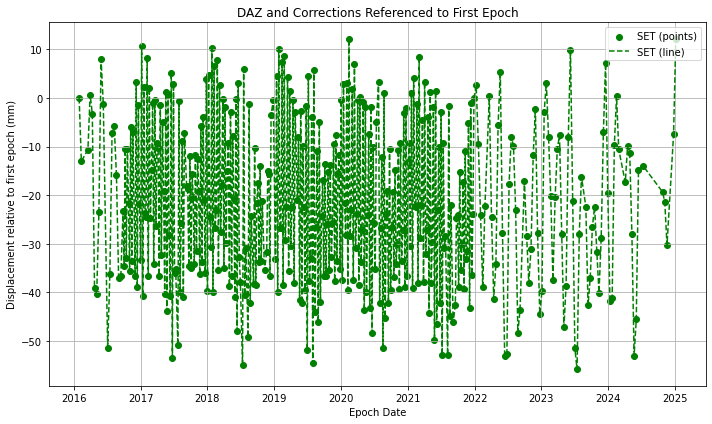

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Copy and convert
dazes = dazes_021D.copy()
dazes = dazes[dazes['epoch'] >= '2016-01-01']
dazes['epoch'] = pd.to_datetime(dazes_021D['epoch'])
dazes['daz'] = dazes['daz'] * 14000
dazes['iono'] = dazes['daz_iono'] * 14000
dazes['set'] = dazes['daz_SET'] * 14000
dazes['daz_SET'] = dazes['daz_SET'] - dazes['daz_SET'].iloc[0]

# Sort by epoch
dazes = dazes.sort_values('epoch').reset_index(drop=True)


# Reference to first epoch
dazes['daz'] -= dazes['daz'].iloc[0]
dazes['iono'] -= dazes['iono'].iloc[0]
dazes['set'] -= dazes['set'].iloc[0]

# Convert time to float in years
t0 = dazes['epoch'].min()
dazes['time_yrs'] = (dazes['epoch'] - t0).dt.total_seconds() / (365.25 * 24 * 3600)
dazes['epoch']= dazes['epoch'].sort_values()
# Plot
plt.figure(figsize=(10, 6))

# # DAZ
# plt.scatter(dazes['epoch'], dazes['daz'], color='k', label='DAZ (points)')
# plt.plot(dazes['epoch'], dazes['daz'], color='k', linestyle='--', label='DAZ (line)')

# # Iono
# plt.scatter(dazes['epoch'], dazes['iono'], color='blue', label='Ionosphere (points)')
# plt.plot(dazes['epoch'], dazes['iono'], color='blue', linestyle='--', label='Ionosphere (line)')

# SET
plt.scatter(dazes['epoch'], dazes['set'], color='green', label='SET (points)')
plt.plot(dazes['epoch'], dazes['set'], color='green', linestyle='--', label='SET (line)')

plt.xlabel("Epoch Date")
plt.ylabel("Displacement relative to first epoch (mm)")
plt.title("DAZ and Corrections Referenced to First Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
dazes['epoch']

0     2022-08-26
1     2022-09-07
2     2022-10-01
3     2022-10-13
4     2022-10-25
         ...    
424   2024-10-26
425   2024-11-07
426   2024-11-19
427   2024-12-25
428   2025-01-06
Name: epoch, Length: 429, dtype: datetime64[ns]